In [1]:
import os, sys, re
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint_adjoint as odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
os.chdir("../../")

In [3]:
adata = sc.read_h5ad("data/klein_subset.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [10]:
# create new adata with DM coordinate as X
new_ad = ad.AnnData(
    X = adata.obsm['DM_EigenVectors_multiscaled'],
    obs = adata.obs.copy(),
    var = pd.DataFrame(['DM_%d'%d for d in range(5)]).set_index(0)
)

new_ad.obsp['connectivities'] = adata.obsp['connectivities'].copy()
new_ad.obsp['distances'] = adata.obsp['distances'].copy()
new_ad.layers['DM'] = new_ad.X.copy()
new_ad.obsm["X_pca"] = adata.obsm["X_pca"]
new_ad.obsm["X_umap"] = adata.obsm["X_umap"]

for key in ['v7_d2_v', 'v7_d4_v', 'v7_d6_v']:
    new_ad.layers[key] = np.load(f"results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/{key}_highdim_v.npy")

In [21]:
scv.pp.neighbors(new_ad, n_neighbors=15)

computing neighbors
    finished (0:00:04) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


# load model and generate v

```python
device = model.device
cellstate = adata.obsm['DM_EigenVectors_multiscaled']
s = torch.from_numpy(cellstate).to(device).requires_grad_()

new_ad.layers['v7_d2_v'] = model.v(s, torch.tensor([0.2]*cellstate.shape[0]).to(device).requires_grad_()).detach().numpy()
new_ad.layers['v7_d4_v'] = model.v(s, torch.tensor([0.4]*cellstate.shape[0]).to(device).requires_grad_()).detach().numpy()
new_ad.layers['v7_d6_v'] = model.v(s, torch.tensor([0.6]*cellstate.shape[0]).to(device).requires_grad_()).detach().numpy()

for key in ['v7_d2_v', 'v7_d4_v', 'v7_d6_v']:
    np.save(f"results/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/{key}_highdim_v.npy",
             new_ad.layers[key])

```

In [22]:
scv.tl.velocity_graph(new_ad, vkey='v7_d4_v', xkey='DM', n_jobs=20)

computing velocity graph (using 20/256 cores)


  0%|          | 0/47907 [00:00<?, ?cells/s]

    finished (0:00:11) --> added 
    'v7_d4_v_graph', sparse matrix with cosine correlations (adata.uns)


In [24]:
new_ad

AnnData object with n_obs × n_vars = 47907 × 5
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'v7_d6_v_self_transition', 'v7_d4_v_self_transition'
    uns: 'neighbors', 'v7_d6_v_graph', 'v7_d6_v_graph_neg', 'v7_d6_v_params', 'v7_d4_v_graph', 'v7_d4_v_graph_neg', 'v7_d4_v_params'
    obsm: 'X_pca', 'X_umap', 'v7_d6_v_umap', 'v7_d4_v_umap'
    layers: 'DM', 'v7_d2_v', 'v7_d4_v', 'v7_d6_v'
    obsp: 'connectivities', 'distances'

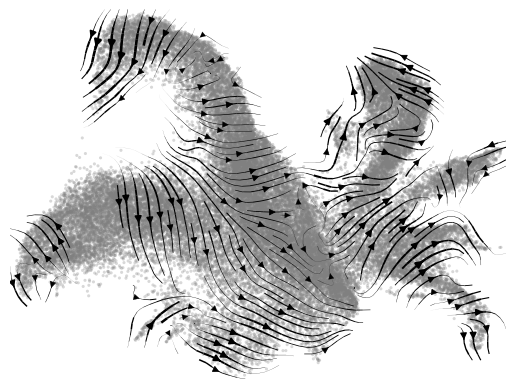

In [27]:
scv.pl.velocity_embedding_stream(new_ad, vkey='v7_d4_v', basis='umap',integration_direction='both')

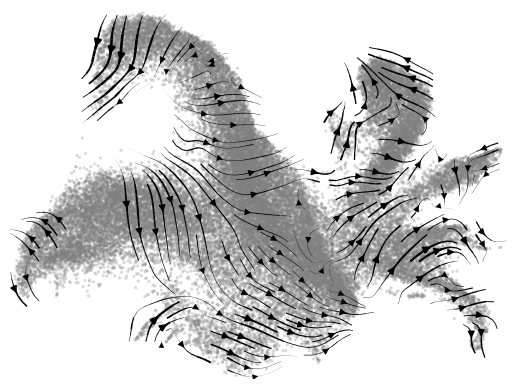

In [ ]:
scv.pl.velocity_embedding_stream(new_ad, vkey='v7_d4_v', basis='umap',integration_direction='forward')

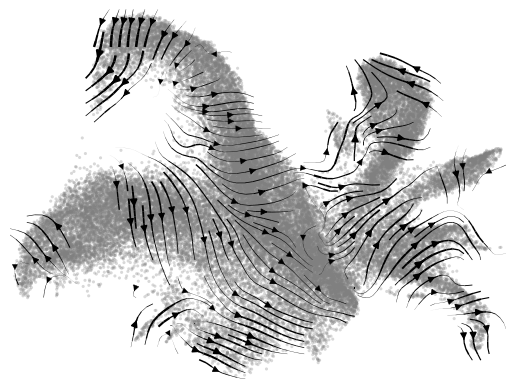

In [26]:
scv.pl.velocity_embedding_stream(new_ad, vkey='v7_d4_v', basis='umap',integration_direction='backward')

# integral velocity

In [5]:
from torchdiffeq import odeint

In [ ]:
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=53-total_loss=0.21702482.ckpt"

model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

In [17]:
cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

In [18]:
def v_ode(t, state):
    s_in = state
    t_in = torch.full((s_in.shape[0],), t.item()).float().to(s_in.device)
    # dsdt
    return pde_model.v(s_in, t_in) 

In [43]:
s_int.shape

(18, 47907, 5)

# vis 1 in DM space

In [49]:
# subset some cells

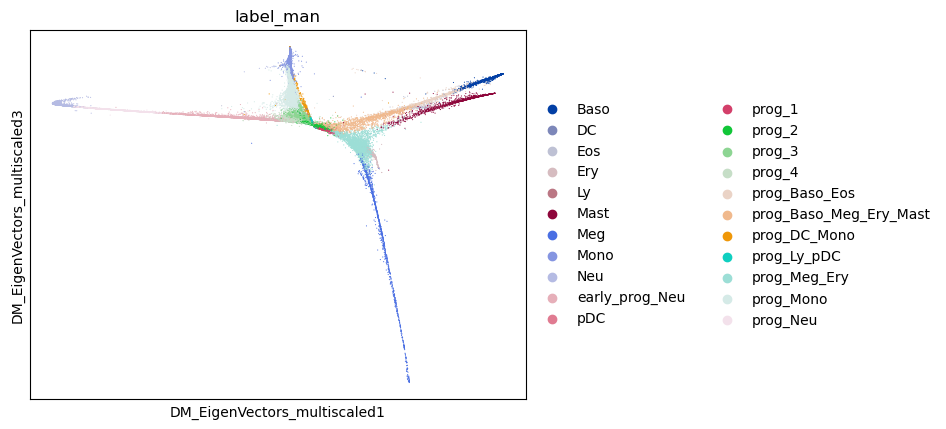

In [ ]:
sc.pl.embedding(adata, basis=cellstate_key, dimensions=[0,2], color='label_man',)

In [24]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [35]:
colors = cm.Reds(0.1)

In [126]:
coords = adata[subset_prog].obsm[cellstate_key][:,[0,2]].copy()

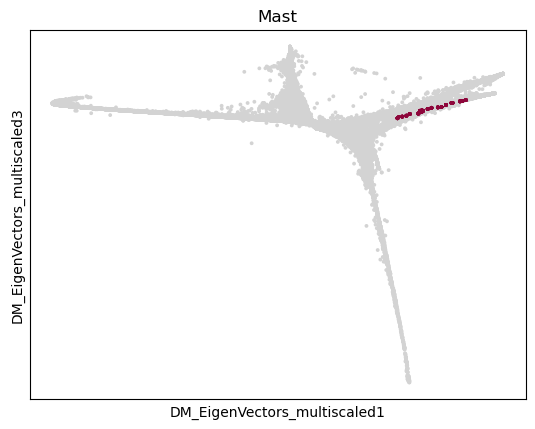

In [268]:
ct = 'Mast'

obs_names = adata.obs_names
prog_cb = adata.obs.query("`label_man` == @ct & `Time_point` == '2.0'").index
subset_prog = np.random.choice(prog_cb, size=200)
subset_index = [np.where(obs_names == cb)[0].item() for cb in subset_prog]
subset_index[:3]

fig = sc.pl.embedding(adata, basis=cellstate_key, dimensions=[0,2], size=30, return_fig=True, show=False)
sc.pl.embedding(adata[subset_prog], color='label_man', legend_loc='left', basis=cellstate_key, dimensions=[0,2], size=30, ax=fig.gca(), title=ct)

In [269]:
chunk_size = 5000

t_list = adata.uns['pop']['t'] 
t_list = t_list / t_list[0]
s_ts = torch.from_numpy(adata[subset_prog].obsm[cellstate_key]).float().to(device)
# t_ts = torch.from_numpy(adata.uns['pop']['t']).float().to(device) /10

it = 0
span = 1
s_int = []
for it in range(n_timepoint-span):
    
    t0 = t_list[it]
    t1 = t_list[it+span]

    s_out_list = []

    for i in tqdm(range(0, len(s_ts), chunk_size)):                              
        
        s_in = s_ts[i:i+chunk_size]
        with torch.no_grad():
            s_t = odeint(v_ode, 
                        y0 = s_in, 
                        t = torch.linspace(t0, t1, 11),
                        atol = 1e-8,
                        rtol = 1e-8,
                        method = 'dopri5')
            s_out_list.append(s_t.detach().cpu().numpy())

    s_int.append(np.concatenate(s_out_list, axis=1))

s_int = np.stack(s_int,  axis=0)

100%|██████████| 1/1 [00:00<00:00, 30.86it/s]


Text(0.5, 1.0, 'Mast')

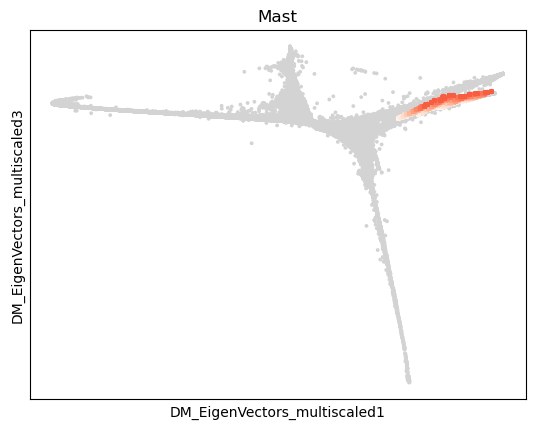

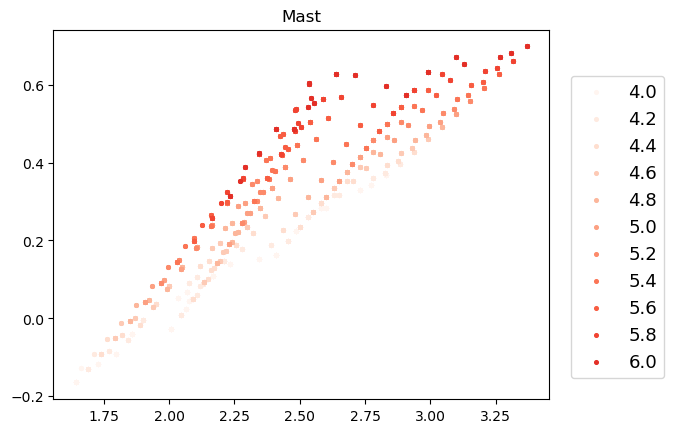

In [270]:
fig = sc.pl.embedding(adata, basis=cellstate_key, dimensions=[0,2], size=30, return_fig=True, show=False)
# fig = plt.figure()
ax=fig.gca() 

coords = s_int[1][:, :,[0,2]].copy()
for i in range(9):
    ax.scatter(coords[i,:,0], coords[i,:,1], color=cm.Reds(i/15),  s=7)
ax.set_title(ct)

fig = plt.figure()
ax=fig.gca() 
for i in range(11):
    ax.scatter(coords[i,:,0], coords[i,:,1], color=cm.Reds(i/15),  s=7 , label=str(np.linspace(t0, t1, 11)[i]*2))
plt.legend(bbox_to_anchor=[1.2,0,0.05,0.9], fontsize=13)
ax.set_title(ct)